# 1) Load the data and explore them, showing size, structure and histogramsof numeric data; show the histogram of the frequencies of the class la-bels, contained in the “language” column . . 

The size is 4277 and the shape is (329, 13)


,language,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
0,ES,7.071476,-6.512900,7.650800,11.150783,-7.657312,12.484021,-11.709772,3.426596,1.462715,-2.812753,0.866538,-5.244274
1,ES,10.982967,-5.157445,3.952060,11.529381,-7.638047,12.136098,-12.036247,3.491943,0.595441,-4.508811,2.332147,-6.221857
2,ES,7.827108,-5.477472,7.816257,9.187592,-7.172511,11.715299,-13.847214,4.574075,-1.687559,-7.204041,-0.011847,-6.463144
3,ES,6.744083,-5.688920,6.546789,9.000183,-6.924963,11.710766,-12.374388,6.169879,-0.544747,-6.019237,1.358559,-6.356441
4,ES,5.836843,-5.326557,7.472265,8.847440,-6.773244,12.677218,-12.315061,4.416344,0.193500,-3.644812,2.151239,-6.816310


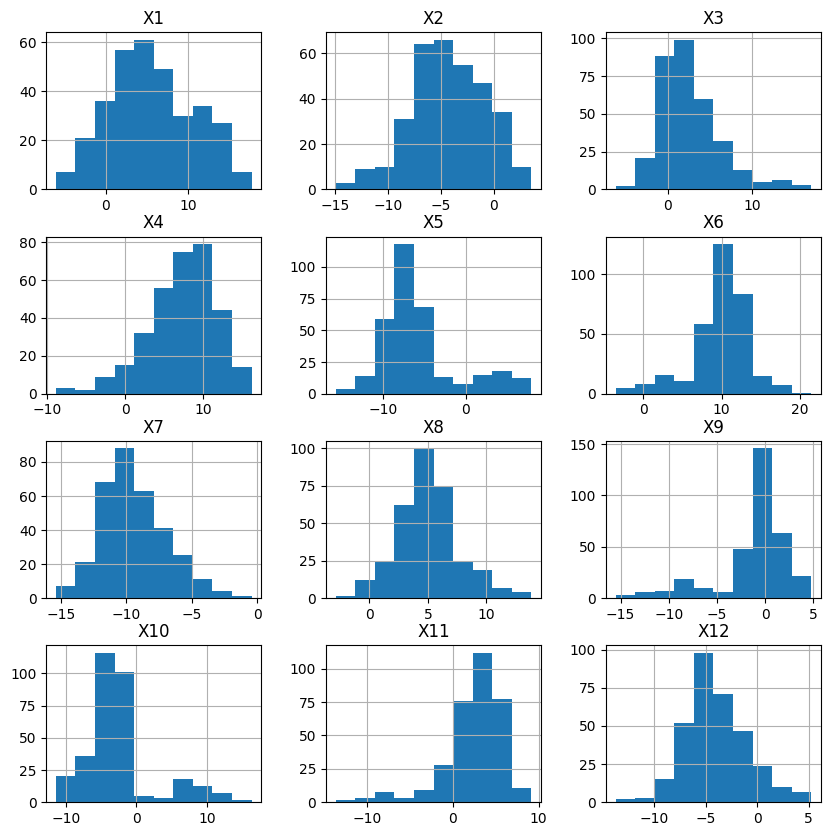

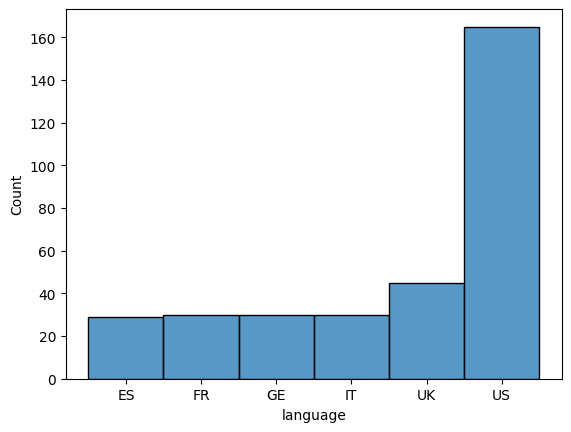

In [27]:
import pandas as pd
from pandas.api.types import is_numeric_dtype
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Load data
data = pd.read_csv("./exam2022_01_13.csv")

# Showing size
print(f"The size is {data.size} and the shape is {data.shape}")

# Show the structure
display(data.head())

# Show histograms of numeric data
numeric_columns = [col for col in data.columns if is_numeric_dtype(data[col].dtype)]
data.hist(column=numeric_columns, figsize=[10,10]);
plt.show()

# Frequencies of the language column
warnings.filterwarnings("ignore")
sns.histplot(data, x="language");
plt.show()


# 2) Drop the rows with NaN values, if any, show the shape of the datasetafter this cleaning

In [28]:
df = data.dropna()
df.shape

(321, 13)

# 3) tune the hyper–parameters of Model1 with Cross Validation on thetraining set, optimize for recall_macro

For the model Decision Tree:
Best params : {'criterion': 'gini', 'max_depth': 7, 'splitter': 'best'}
Classification report : 
              precision    recall  f1-score   support

          ES       0.78      0.88      0.82         8
          FR       0.50      0.71      0.59         7
          GE       0.33      0.33      0.33         9
          IT       0.36      0.36      0.36        11
          UK       0.20      0.17      0.18         6
          US       0.84      0.78      0.81        40

    accuracy                           0.63        81
   macro avg       0.50      0.54      0.52        81
weighted avg       0.64      0.63      0.63        81



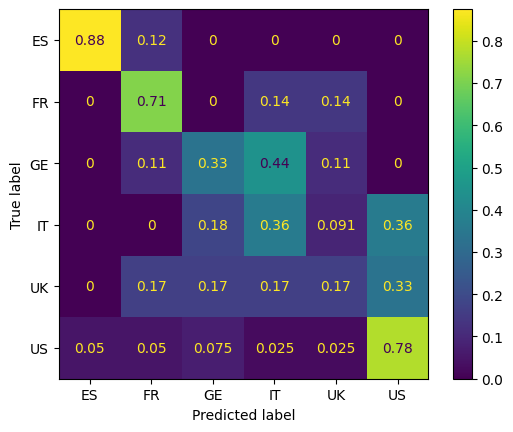



For the model Random forest:
Best params : {'criterion': 'gini', 'max_depth': 14, 'n_estimators': 50}
Classification report : 
              precision    recall  f1-score   support

          ES       1.00      1.00      1.00         8
          FR       0.83      0.71      0.77         7
          GE       0.80      0.44      0.57         9
          IT       0.50      0.36      0.42        11
          UK       0.60      0.50      0.55         6
          US       0.78      0.95      0.85        40

    accuracy                           0.77        81
   macro avg       0.75      0.66      0.69        81
weighted avg       0.75      0.77      0.75        81



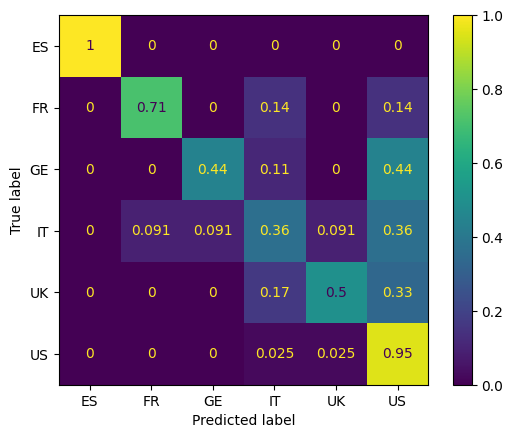

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

random_state = 42

# Extract train-test
X = df.iloc[:,1:]
y = df.iloc[:,0]
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=random_state)

# Define the 2 models
models = {
    "dt" : {
        "name" : "Decision Tree",
        "classfier" : DecisionTreeClassifier(random_state=random_state),
        "params" : {
            "criterion" : ["gini", "entropy", "log_loss"],
            "splitter" : ["best", "random"],
            "max_depth" : [*range(1, 21)]
        }
    },
    "rf" : {
        "name" : "Random forest",
        "classfier" : RandomForestClassifier(random_state=random_state, n_jobs=-1),
        "params" : {
            "n_estimators" : [*range(10, 51, 10)],
            "criterion" : ["gini", "entropy", "log_loss"],
            "max_depth" : [*range(1, 21)]
        }
    }
}

# Unique cycle for both models
for k, model in models.items():
    print(f"For the model {model['name']}:")
    
    gscv = GridSearchCV(
        estimator=model["classfier"],
        param_grid=model["params"],
        scoring="recall_macro",
        n_jobs=-1
    )
    gscv.fit(X_train, y_train)
    
    best_params = gscv.best_params_
    best_model = model["classfier"].set_params(**best_params).fit(X_train,y_train)
    y_pred = best_model.predict(X_test)
    
    print(f"Best params : {best_params}")
    print(f"Classification report : \n{classification_report(y_test, y_pred)}")
    labels = df["language"].unique()
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred, normalize="true", labels=labels), 
        display_labels=labels
    ).plot()
    plt.show()
    
    print("\n", "="*80, "\n")    